In [1]:
from pathlib import Path
import random
import time
import warnings

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image

import ultralytics
from ultralytics import YOLO

# Semilla para que los resultados sean reproducibles
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Dispositivo en el formato que espera Ultralytics
if torch.cuda.is_available():
    DEVICE = 0              # primera GPU NVIDIA
elif torch.backends.mps.is_available():
    DEVICE = "mps"          # GPU de Apple (M1/M2/M3...)
else:
    DEVICE = "cpu"

# En Apple Silicon, PyTorch avisa en cada iteración que algunas operaciones no son deterministas
warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")

# Rutas absolutas del dataset y de los resultados
DATA_DIR = Path("../data/license-plates").resolve()
RUNS_DIR = Path("runs").resolve()

print(f"Ultralytics {ultralytics.__version__} | PyTorch {torch.__version__} | Dispositivo: {DEVICE}")
print(f"Dataset:    {DATA_DIR}")
print(f"Resultados: {RUNS_DIR}")

Creating new Ultralytics Settings v0.0.8 file  
View Ultralytics Settings with 'yolo settings' or at 'D:\Users\ClientAdm\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.170 | PyTorch 2.14.0+cpu | Dispositivo: cpu
Dataset:    D:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\data\license-plates
Resultados: D:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\notebooks\runs


In [2]:
def mostrar(imagen, titulo=None, ax=None, figsize=(8, 6)):
    # Muestra una imagen (ruta, PIL o arreglo RGB) con matplotlib.
    if isinstance(imagen, (str, Path)):
        imagen = Image.open(imagen)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    ax.imshow(imagen)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, fontsize=10)
    return ax

In [3]:
SPLITS = ["train", "val"]

for split in SPLITS:
    n_imagenes = len(list((DATA_DIR / "images" / split).glob("*.jpg")))
    n_etiquetas = len(list((DATA_DIR / "labels" / split).glob("*.txt")))
    print(f"{split:>5s} → {n_imagenes} imágenes | {n_etiquetas} etiquetas")

print("\nContenido de la carpeta:")
for elemento in sorted(DATA_DIR.iterdir()):
    print("  ", elemento.name + ("/" if elemento.is_dir() else ""))

train → 1526 imágenes | 1526 etiquetas
  val → 169 imágenes | 169 etiquetas

Contenido de la carpeta:
   classes.txt
   data.yaml
   dataset.yaml
   images/
   labels/
   train/
   val/


In [4]:
print((DATA_DIR / "dataset.yaml").read_text())

train: /kaggle/input/license-plate-dataset/archive/images/train
val: /kaggle/input/license-plate-dataset/archive/images/val

nc: 1,  # Number of classes
names: {0: 'license_plate'}


In [5]:
def origen(ruta):
    # 'video8_2090.jpg' → 'video8'; cualquier otra imagen → 'foto suelta'
    nombre = Path(ruta).name
    return nombre.split("_")[0] if nombre.startswith("video") else "foto suelta"


for split in SPLITS:
    conteo = pd.Series([origen(r) for r in (DATA_DIR / "images" / split).glob("*.jpg")]).value_counts()
    print(f"{split}: " + ", ".join(f"{k} ({v})" for k, v in conteo.items()))

train: foto suelta (1054), video11 (185), video3 (80), video2 (76), video4 (73), video10 (50), video12 (8)
val: video8 (70), video6 (43), video5 (33), video9 (20), video4 (2), video (1)


In [6]:
imgs_train = sorted((DATA_DIR / "images" / "train").glob("*.jpg"))
imgs_val = sorted((DATA_DIR / "images" / "val").glob("*.jpg"))


def ruta_etiqueta(ruta_img):
    # images/<split>/nombre.jpg  →  labels/<split>/nombre.txt
    ruta_img = Path(ruta_img)
    return DATA_DIR / "labels" / ruta_img.parent.name / f"{ruta_img.stem}.txt"


ejemplo = imgs_train[0]
print("Imagen: ", ejemplo.name)
print("Etiqueta:", ruta_etiqueta(ejemplo).name)
print("Contenido del .txt:", ruta_etiqueta(ejemplo).read_text())
print("Tamaño de la imagen (ancho, alto):", Image.open(ejemplo).size)

Imagen:  0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.jpg
Etiqueta: 0073797c-a755-4972-b76b-8ef2b31d44ab___new_IMG_20160315_071740.jpg.txt
Contenido del .txt: 0 0.479000 0.701493 0.398000 0.149254

Tamaño de la imagen (ancho, alto): (500, 335)


Etiqueta YOLO (normalizada): [          0       0.479     0.70149       0.398     0.14925]
Caja en píxeles (x1, y1, x2, y2): [        140         210         339         260]


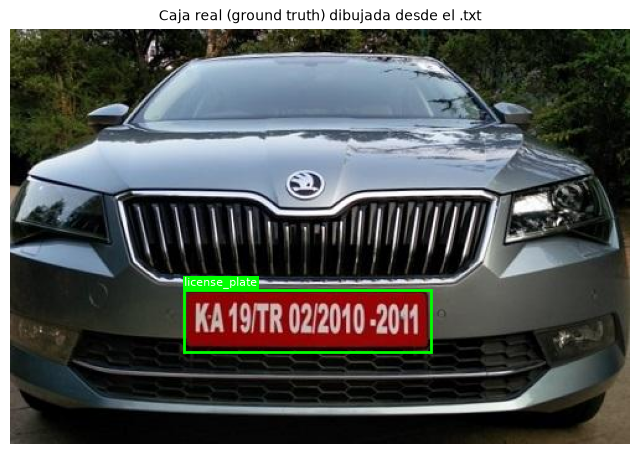

In [7]:
def leer_etiquetas(ruta_txt):
    # Devuelve un arreglo (N, 5): clase, xc, yc, w, h. Si no hay objetos, (0, 5).
    ruta_txt = Path(ruta_txt)
    if not ruta_txt.exists() or ruta_txt.stat().st_size == 0:
        return np.zeros((0, 5))
    return np.loadtxt(ruta_txt, ndmin=2)


def yolo_a_xyxy(etiquetas, ancho, alto):
    # Convierte (xc, yc, w, h) normalizados a (x1, y1, x2, y2) en píxeles.
    xc, yc, w, h = etiquetas[:, 1], etiquetas[:, 2], etiquetas[:, 3], etiquetas[:, 4]
    return np.stack([(xc - w / 2) * ancho, (yc - h / 2) * alto,
                     (xc + w / 2) * ancho, (yc + h / 2) * alto], axis=1)


def dibujar_cajas(ax, cajas, color, textos=None):
    # Dibuja cajas (x1, y1, x2, y2) en un eje de matplotlib, con un texto opcional encima.
    for i, (x1, y1, x2, y2) in enumerate(cajas):
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2, edgecolor=color))
        if textos is not None:
            ax.text(x1, y1 - 3, textos[i], color="white", fontsize=8,
                    bbox=dict(facecolor=color, pad=1, lw=0))


# Aplicamos las funciones a la imagen de ejemplo
etiquetas = leer_etiquetas(ruta_etiqueta(ejemplo))
ancho, alto = Image.open(ejemplo).size
cajas = yolo_a_xyxy(etiquetas, ancho, alto)
print("Etiqueta YOLO (normalizada):", etiquetas[0])
print("Caja en píxeles (x1, y1, x2, y2):", cajas[0].round(1))

ax = mostrar(ejemplo, "Caja real (ground truth) dibujada desde el .txt")
dibujar_cajas(ax, cajas, "lime", ["license_plate"])
plt.show()

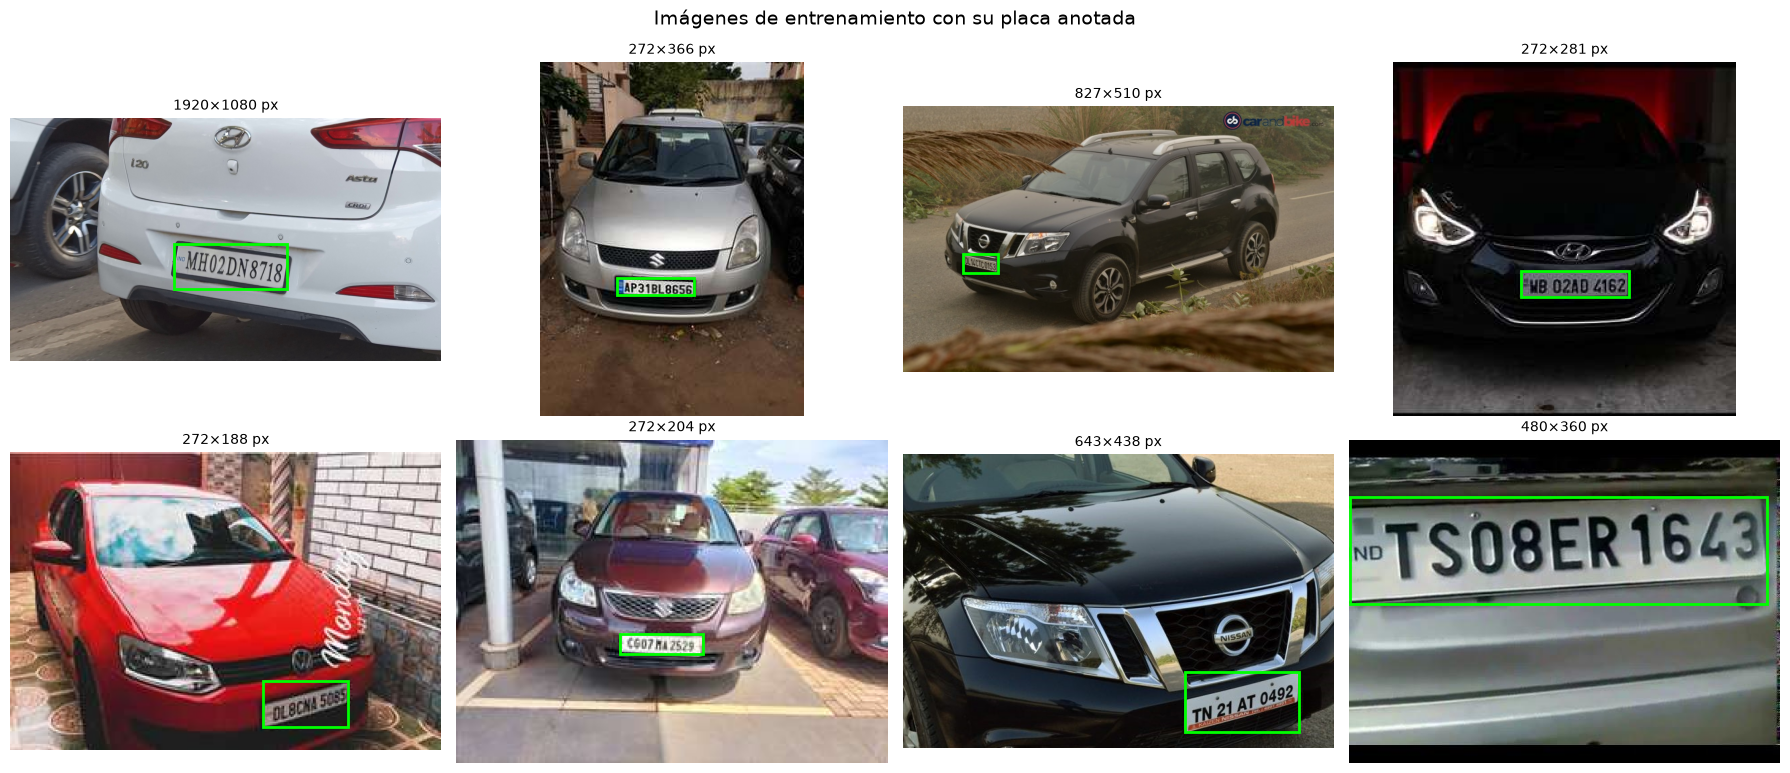

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, ruta in zip(axes.flat, random.sample(imgs_train, 8)):
    img = Image.open(ruta)
    cajas = yolo_a_xyxy(leer_etiquetas(ruta_etiqueta(ruta)), *img.size)
    mostrar(img, f"{img.size[0]}×{img.size[1]} px", ax=ax)
    dibujar_cajas(ax, cajas, "lime")
plt.suptitle("Imágenes de entrenamiento con su placa anotada", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
filas = []
for split in SPLITS:
    for ruta_img in sorted((DATA_DIR / "images" / split).glob("*.jpg")):
        ancho_img, alto_img = Image.open(ruta_img).size   # PIL solo lee la cabecera: es rápido
        for _, xc, yc, w, h in leer_etiquetas(ruta_etiqueta(ruta_img)):
            filas.append({"split": split, "imagen": ruta_img.name,
                          "ancho_img": ancho_img, "alto_img": alto_img,
                          "xc": xc, "yc": yc, "w": w, "h": h})

df_anot = pd.DataFrame(filas)

# Métricas derivadas
df_anot["area_%"] = df_anot["w"] * df_anot["h"] * 100                              # % del área de la imagen
df_anot["aspecto"] = (df_anot["w"] * df_anot["ancho_img"]) / (df_anot["h"] * df_anot["alto_img"])  # ancho / alto en píxeles

objetos_por_imagen = df_anot.groupby(["split", "imagen"]).size()
print(f"Total de anotaciones: {len(df_anot)}")
print(f"Objetos por imagen: mínimo {objetos_por_imagen.min()}, máximo {objetos_por_imagen.max()}")
df_anot[["ancho_img", "alto_img", "area_%", "aspecto"]].describe().round(2)

Total de anotaciones: 1695
Objetos por imagen: mínimo 1, máximo 1


,ancho_img,alto_img,area_%,aspecto
count,1695.00,1695.00,1695.00,1695.00
mean,654.55,554.53,3.48,3.55
std,499.59,321.80,5.12,0.94
min,78.00,87.00,0.16,0.84
25%,272.00,333.00,1.37,2.97
50%,485.00,451.00,2.07,3.63
75%,859.50,734.00,3.57,4.22
max,4000.00,3000.00,69.35,10.04


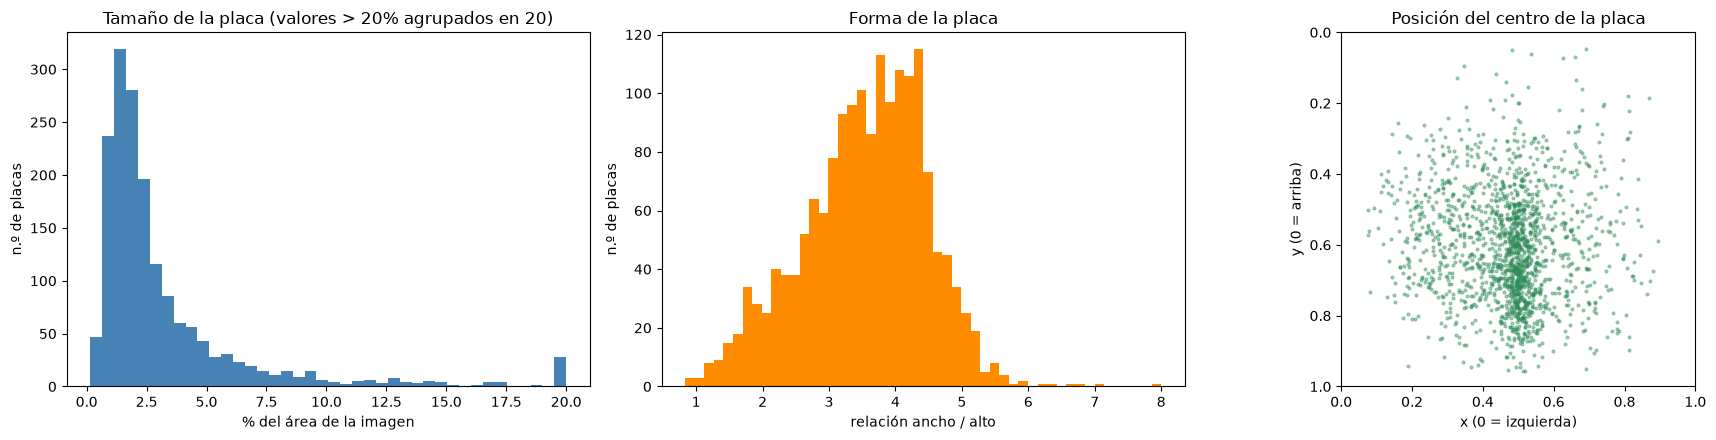

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(df_anot["area_%"].clip(upper=20), bins=40, color="steelblue")
axes[0].set(title="Tamaño de la placa (valores > 20% agrupados en 20)", xlabel="% del área de la imagen",
            ylabel="n.º de placas")

axes[1].hist(df_anot["aspecto"].clip(upper=8), bins=50, color="darkorange")
axes[1].set(title="Forma de la placa", xlabel="relación ancho / alto", ylabel="n.º de placas")

axes[2].scatter(df_anot["xc"], df_anot["yc"], s=4, alpha=0.4, color="seagreen")
axes[2].set(title="Posición del centro de la placa", xlabel="x (0 = izquierda)", ylabel="y (0 = arriba)",
            xlim=(0, 1), ylim=(1, 0))    # invertimos y: en imágenes, y crece hacia abajo
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

In [11]:
tamanos = (df_anot["ancho_img"].astype(str) + "×" + df_anot["alto_img"].astype(str)).value_counts()
print(f"Tamaños distintos de imagen: {len(tamanos)}")
tamanos.head(8)

Tamaños distintos de imagen: 1073


272×363      203
272×204       93
1920×1080     89
272×153       19
272×604       19
272×484       19
272×590       11
272×364       11
Name: count, dtype: int64

In [12]:
CLASES = {0: "license_plate"}

config = {
    "path": str(DATA_DIR),       # raíz del dataset (ruta absoluta)
    "train": "images/train",     # rutas relativas a 'path'
    "val": "images/val",
    "names": CLASES,
}

DATA_YAML = DATA_DIR / "data.yaml"
DATA_YAML.write_text(yaml.safe_dump(config, sort_keys=False))
print(DATA_YAML.read_text())

path: D:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\data\license-plates
train: images/train
val: images/val
names:
  0: license_plate



In [13]:
modelo_coco = YOLO("yolo26n.pt")

n_params = sum(p.numel() for p in modelo_coco.model.parameters())
print(f"Parámetros: {n_params / 1e6:.1f} millones")
print(f"Clases que conoce ({len(modelo_coco.names)}):")
print(", ".join(modelo_coco.names.values()))

Parámetros: 2.6 millones
Clases que conoce (80):
person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy bear, hair drier, toothbrush


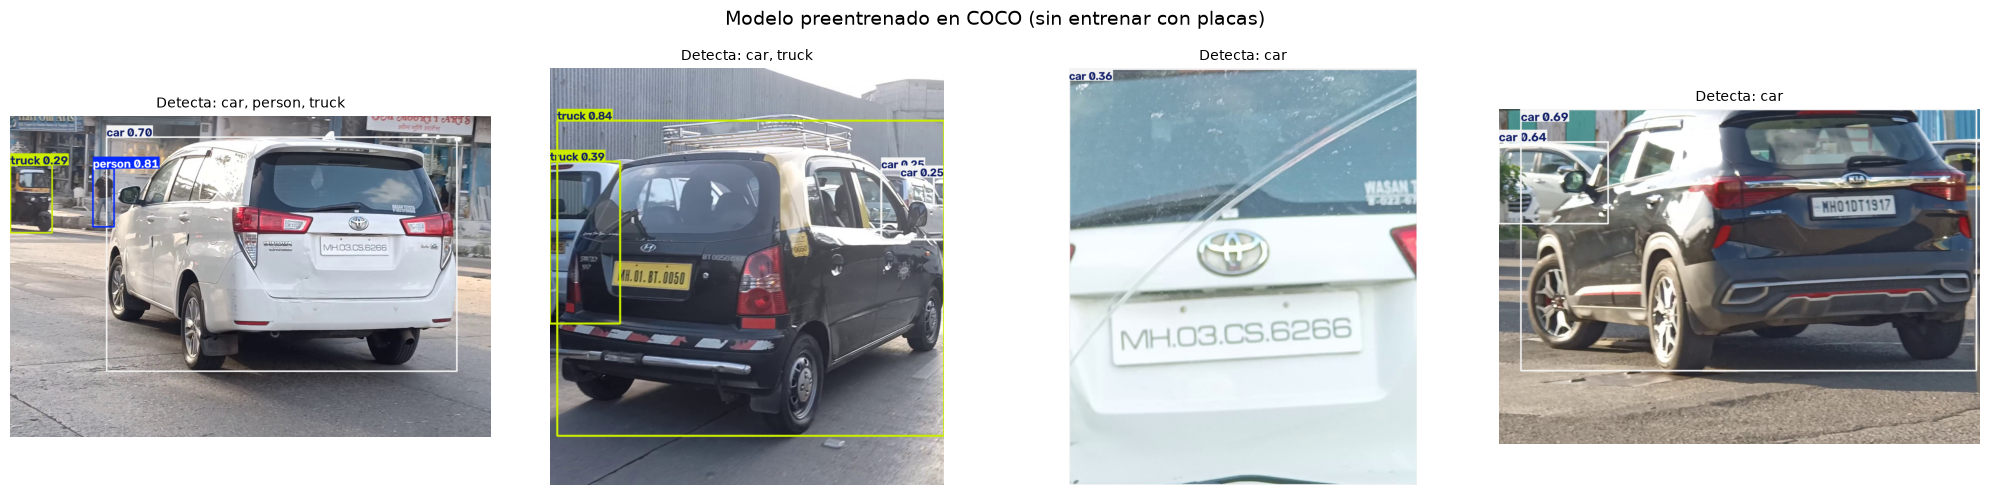

In [14]:
muestra_val = random.sample(imgs_val, 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, ruta in zip(axes, muestra_val):
    resultado = modelo_coco.predict(ruta, conf=0.25, device=DEVICE, verbose=False)[0]
    detectado = sorted({resultado.names[int(c)] for c in resultado.boxes.cls}) or ["nada"]
    mostrar(resultado.plot()[..., ::-1], "Detecta: " + ", ".join(detectado), ax=ax)
plt.suptitle("Modelo preentrenado en COCO (sin entrenar con placas)", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
resultado = modelo_coco.predict(muestra_val[0], conf=0.25, device=DEVICE, verbose=False)[0]

tabla = pd.DataFrame(resultado.boxes.xyxy.cpu().numpy().round(1), columns=["x1", "y1", "x2", "y2"])
tabla["clase"] = [resultado.names[int(c)] for c in resultado.boxes.cls]
tabla["confianza"] = resultado.boxes.conf.cpu().numpy().round(3)
tabla

,x1,y1,x2,y2,clase,confianza
0,278.399994,176.800003,349.200012,372.299988,person,0.813
1,324.299988,71.900002,1500.000000,857.500000,car,0.704
2,1.400000,165.899994,141.899994,392.799988,truck,0.291


In [ ]:
EPOCHS = 20
BATCH = 16
IMGSZ = 640
NOMBRE_RUN = "placas_yolo26n"
ENTRENAR_DE_NUEVO = True

SAVE_DIR = RUNS_DIR / NOMBRE_RUN          # aquí se guardan pesos, gráficos y métricas
BEST_PT = SAVE_DIR / "weights" / "best.pt"

if BEST_PT.exists() and not ENTRENAR_DE_NUEVO:
    print(f"Ya existe un modelo entrenado: {BEST_PT}")
else:
    modelo = YOLO("yolo26n.pt")           # pesos de COCO → transfer learning
    inicio = time.time()
    modelo.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        patience=10,
        device=DEVICE,
        seed=SEED,
        project=str(RUNS_DIR),
        name=NOMBRE_RUN,
        exist_ok=True,                    # sobrescribe la carpeta si vuelves a entrenar
        plots=True,
    )
    print(f"\nEntrenamiento completado en {(time.time() - inicio) / 60:.1f} minutos")

print("Archivos generados:")
for archivo in sorted(SAVE_DIR.iterdir()):
    print("  ", archivo.name)

Ultralytics 8.4.170  Python-3.13.14 torch-2.14.0+cpu CPU (Intel Core i7-8650U 1.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Users\ClientAdm\Documents\datascience-g8\01-python-intro\data\license-plates\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

In [ ]:
mostrar(SAVE_DIR / "train_batch0.jpg", "Un lote de entrenamiento con aumentación de datos", figsize=(10, 10))
plt.show()

In [ ]:
df_res = pd.read_csv(SAVE_DIR / "results.csv")
df_res.columns = df_res.columns.str.strip()

perdidas = [c.removeprefix("train/") for c in df_res.columns if c.startswith("train/")]
metricas = ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]

fig, axes = plt.subplots(1, len(perdidas) + 1, figsize=(5 * (len(perdidas) + 1), 4))
for ax, perdida in zip(axes, perdidas):
    ax.plot(df_res["epoch"], df_res[f"train/{perdida}"], "o-", ms=3, label="train")
    ax.plot(df_res["epoch"], df_res[f"val/{perdida}"], "s-", ms=3, label="validación")
    ax.set(title=perdida, xlabel="época")
    ax.legend()
    ax.grid(alpha=0.3)

for metrica in metricas:
    axes[-1].plot(df_res["epoch"], df_res[metrica], "o-", ms=3,
                  label=metrica.split("/")[1].replace("(B)", ""))
axes[-1].set(title="Métricas en validación", xlabel="época", ylim=(0, 1))
axes[-1].legend()
axes[-1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

mejor = df_res.loc[df_res["metrics/mAP50-95(B)"].idxmax()]
print(f"Mejor época: {int(mejor['epoch'])} | "
      f"mAP50 = {mejor['metrics/mAP50(B)']:.3f} | mAP50-95 = {mejor['metrics/mAP50-95(B)']:.3f}")

In [ ]:
def iou(caja_a, caja_b):
    # IoU entre dos cajas en formato (x1, y1, x2, y2).
    # 1. Esquinas del rectángulo de intersección
    x1 = max(caja_a[0], caja_b[0])
    y1 = max(caja_a[1], caja_b[1])
    x2 = min(caja_a[2], caja_b[2])
    y2 = min(caja_a[3], caja_b[3])

    # 2. Áreas (si no se tocan, la intersección es 0)
    interseccion = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = (caja_a[2] - caja_a[0]) * (caja_a[3] - caja_a[1])
    area_b = (caja_b[2] - caja_b[0]) * (caja_b[3] - caja_b[1])
    union = area_a + area_b - interseccion
    return interseccion / union if union > 0 else 0.0


# Casos de prueba
print(f"Cajas idénticas:           IoU = {iou([0, 0, 10, 10], [0, 0, 10, 10]):.2f}")
print(f"Desplazada a la mitad:     IoU = {iou([0, 0, 10, 10], [5, 0, 15, 10]):.2f}")
print(f"Una dentro de otra (36%):  IoU = {iou([0, 0, 10, 10], [2, 2, 8, 8]):.2f}")
print(f"Sin solapamiento:          IoU = {iou([0, 0, 10, 10], [20, 20, 30, 30]):.2f}")

In [ ]:
modelo_best = YOLO(BEST_PT)


def cajas_reales(ruta_img):
    # Cajas ground truth de una imagen, en píxeles (x1, y1, x2, y2).
    ancho, alto = Image.open(ruta_img).size
    return yolo_a_xyxy(leer_etiquetas(ruta_etiqueta(ruta_img)), ancho, alto)


ruta = imgs_val[0]
resultado = modelo_best.predict(ruta, conf=0.25, device=DEVICE, verbose=False)[0]
real = cajas_reales(ruta)[0]
predicha = resultado.boxes.xyxy.cpu().numpy()[0]

ax = mostrar(ruta, f"IoU entre la caja real y la predicha = {iou(real, predicha):.3f}", figsize=(9, 6))
dibujar_cajas(ax, [real], "lime", ["real"])
dibujar_cajas(ax, [predicha], "red", [f"predicha {resultado.boxes.conf[0]:.2f}"])
plt.show()

In [ ]:
metricas_val = modelo_best.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name="placas_val",
    exist_ok=True,
    verbose=False,
)

print(f"Precisión: {metricas_val.box.mp:.3f}")
print(f"Recall:    {metricas_val.box.mr:.3f}")
print(f"mAP50:     {metricas_val.box.map50:.3f}")
print(f"mAP50-95:  {metricas_val.box.map:.3f}")

In [ ]:
mostrar(Path(metricas_val.save_dir) / "BoxPR_curve.png", "Curva precisión-recall (validación)", figsize=(9, 6))
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, ruta in zip(axes.flat, random.sample(imgs_val, 8)):
    resultado = modelo_best.predict(ruta, conf=0.25, device=DEVICE, verbose=False)[0]
    predichas = resultado.boxes.xyxy.cpu().numpy()
    confianzas = resultado.boxes.conf.cpu().numpy()

    mostrar(ruta, f"{len(predichas)} placa(s) detectada(s)", ax=ax)
    dibujar_cajas(ax, cajas_reales(ruta), "lime")
    dibujar_cajas(ax, predichas, "red", [f"{c:.2f}" for c in confianzas])
plt.suptitle("Verde = caja real | Rojo = predicción del modelo (con su confianza)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def contar_aciertos(cajas_pred, cajas_gt, umbral_iou=0.5):
    # Empareja predicciones con cajas reales (una a una) y devuelve (TP, FP, FN).
    # Las predicciones vienen ordenadas de mayor a menor confianza.
    emparejadas = set()
    tp = 0
    for caja in cajas_pred:
        candidatas = [(iou(caja, gt), g) for g, gt in enumerate(cajas_gt) if g not in emparejadas]
        if candidatas:
            mejor_iou, g = max(candidatas)
            if mejor_iou >= umbral_iou:
                emparejadas.add(g)
                tp += 1
    return tp, len(cajas_pred) - tp, len(cajas_gt) - tp


# Una sola pasada por validación con umbral muy bajo
predicciones = {}
for resultado in modelo_best.predict(imgs_val, conf=0.01, device=DEVICE, stream=True, verbose=False):
    orden = resultado.boxes.conf.cpu().numpy().argsort()[::-1]
    predicciones[resultado.path] = (resultado.boxes.xyxy.cpu().numpy()[orden],
                                    resultado.boxes.conf.cpu().numpy()[orden])

filas = []
for umbral in [0.05, 0.1, 0.25, 0.5, 0.75, 0.9]:
    tp = fp = fn = 0
    for ruta, (cajas, confs) in predicciones.items():
        t, f_p, f_n = contar_aciertos(cajas[confs >= umbral], cajas_reales(ruta))
        tp, fp, fn = tp + t, fp + f_p, fn + f_n
    filas.append({"umbral conf": umbral, "TP": tp, "FP": fp, "FN": fn,
                  "precisión": tp / max(tp + fp, 1), "recall": tp / max(tp + fn, 1)})

df_umbral = pd.DataFrame(filas).set_index("umbral conf")
df_umbral.round(3)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df_umbral.index, df_umbral["precisión"], "o-", label="precisión")
ax.plot(df_umbral.index, df_umbral["recall"], "s-", label="recall")
ax.set(xlabel="umbral de confianza (conf)", ylabel="valor", ylim=(0, 1.05),
       title="Efecto del umbral de confianza (IoU ≥ 0.5)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [ ]:
filas = []
for ruta, (cajas, confs) in predicciones.items():
    cajas_025 = cajas[confs >= 0.25]
    tp, fp, fn = contar_aciertos(cajas_025, cajas_reales(ruta))
    mejor_iou = max((iou(cajas_reales(ruta)[0], c) for c in cajas_025), default=0.0)
    filas.append({"imagen": Path(ruta).name, "ruta": ruta, "n_predichas": len(cajas_025),
                  "mejor_iou": mejor_iou, "FP": fp, "FN": fn})

df_errores = pd.DataFrame(filas).sort_values("mejor_iou")

print(f"Placas encontradas (IoU ≥ 0.5): {(df_errores['FN'] == 0).sum()} de {len(df_errores)}")
print(f"Imágenes con falsos positivos:  {(df_errores['FP'] > 0).sum()}")
print(f"IoU promedio de las detecciones: {df_errores['mejor_iou'].mean():.3f}")

In [ ]:
def mostrar_casos(filas_df, titulo):
    # Dibuja imágenes con la caja real (verde) y las predichas (rojo, con su confianza).
    fig, axes = plt.subplots(1, len(filas_df), figsize=(7 * len(filas_df), 5.5), squeeze=False)
    for ax, (_, fila) in zip(axes[0], filas_df.iterrows()):
        cajas, confs = predicciones[fila["ruta"]]
        mantener = confs >= 0.25
        mostrar(fila["ruta"], f"{fila['imagen']} | mejor IoU = {fila['mejor_iou']:.2f}", ax=ax)
        dibujar_cajas(ax, cajas_reales(fila["ruta"]), "lime")
        dibujar_cajas(ax, cajas[mantener], "red", [f"{c:.2f}" for c in confs[mantener]])
    plt.suptitle(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()


con_fp = df_errores[df_errores["FP"] > 0]
if len(con_fp):
    mostrar_casos(con_fp.head(4), "Imágenes con falsos positivos (verde = real, rojo = predicción)")
else:
    print("No hay falsos positivos con conf = 0.25")

In [ ]:
mostrar_casos(df_errores.head(4), "Las 4 cajas menos ajustadas (verde = real, rojo = predicción)")

In [ ]:
def recortar_placas(ruta_img, modelo=modelo_best, conf=0.25, margen=0.05):
    # Detecta placas y devuelve una lista de (recorte PIL, confianza).
    imagen = Image.open(ruta_img).convert("RGB")
    resultado = modelo.predict(imagen, conf=conf, device=DEVICE, verbose=False)[0]

    recortes = []
    for (x1, y1, x2, y2), confianza in zip(resultado.boxes.xyxy.cpu().numpy(),
                                           resultado.boxes.conf.cpu().numpy()):
        # Agrandamos la caja un poco (margen) para no cortar los bordes de la placa
        dx, dy = (x2 - x1) * margen, (y2 - y1) * margen
        caja = (max(0, x1 - dx), max(0, y1 - dy), min(imagen.width, x2 + dx), min(imagen.height, y2 + dy))
        recortes.append((imagen.crop(caja), float(confianza)))
    return recortes


fig, axes = plt.subplots(3, 4, figsize=(16, 6))
recortes = [r for ruta in random.sample(imgs_val, 20) for r in recortar_placas(ruta)][:12]
for ax, (recorte, confianza) in zip(axes.flat, recortes):
    mostrar(recorte, f"confianza {confianza:.2f}", ax=ax)
for ax in axes.flat[len(recortes):]:
    ax.axis("off")
plt.suptitle("Placas recortadas automáticamente por el detector", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def detectar_placas(ruta_img, modelo=modelo_best, conf=0.25):
    # Muestra la imagen con las placas detectadas y sus recortes.
    resultado = modelo.predict(ruta_img, conf=conf, device=DEVICE, verbose=False)[0]
    recortes = recortar_placas(ruta_img, modelo, conf)

    n_columnas = 1 + max(len(recortes), 1)
    fig, axes = plt.subplots(1, n_columnas, figsize=(6 + 3 * (n_columnas - 1), 4.5),
                             gridspec_kw={"width_ratios": [3] + [1] * (n_columnas - 1)})
    mostrar(resultado.plot()[..., ::-1], f"{len(recortes)} placa(s) detectada(s)", ax=axes[0])
    for ax, (recorte, confianza) in zip(axes[1:], recortes):
        mostrar(recorte, f"recorte ({confianza:.2f})", ax=ax)
    if not recortes:
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()


# Cambia esta ruta por una foto tuya
detectar_placas(random.choice(imgs_val))